#### (d)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import src.util as util

from src.linear_model import LinearModel


In [3]:
x_train, y_train = util.load_dataset('data/ds4_train.csv', add_intercept=True)
x_valid, y_valid = util.load_dataset('data/ds4_valid.csv', add_intercept=True)

In [4]:
class PoissonRegression(LinearModel):
    """Poisson Regression.

    Example usage:
        > clf = PoissonRegression(step_size=lr)
        > clf.fit(x_train, y_train)
        > clf.predict(x_eval)
    """
    
    def h(self, theta, x):
        return np.exp(x @ theta)

    def fit(self, x, y):
        """Run gradient ascent to maximize likelihood for Poisson regression.

        Args:
            x: Training example inputs. Shape (m, n).
            y: Training example labels. Shape (m,).
        """
        # *** START CODE HERE ***
        
        def next_step(theta):
            return self.step_size / m * x.T @ (y-self.h(theta, x))
        
        m, n = x.shape
        
        if not self.theta:
            theta = np.zeros(n)
        else:
            theta = self.theta
        
        step = next_step(theta)
        while np.linalg.norm(step, 1) >= self.eps:
            theta += step
            step = next_step(theta)   
            
        self.theta = theta
        
        # *** END CODE HERE ***

    def predict(self, x):
        """Make a prediction given inputs x.

        Args:
            x: Inputs of shape (m, n).

        Returns:
            Floating-point prediction for each input, shape (m,).
        """
        # *** START CODE HERE ***
        return self.h(self.theta, x)
        # *** END CODE HERE ***

In [5]:
poisson = PoissonRegression(step_size=2e-7)

In [6]:
poisson.fit(x_train, y_train)


In [7]:
def plot(y_label, y_pred, title):
    plt.plot(y_label, 'go', label='label', markersize=4)
    plt.plot(y_pred, 'rx', label='prediction', markersize=3, linewidth=1)
    plt.suptitle(title, fontsize=12)
    plt.legend(loc='upper left')

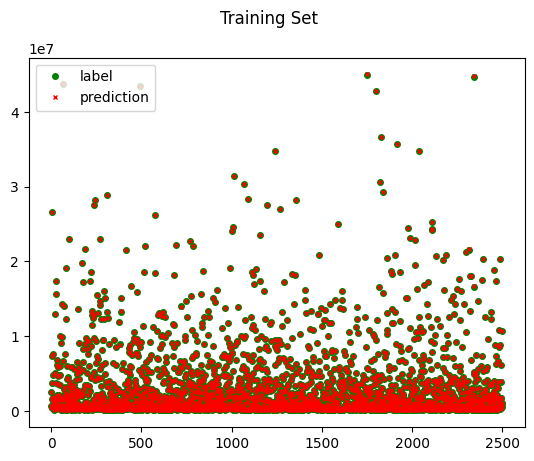

In [8]:
y_train_pred = poisson.predict(x_train)
plot(y_train, y_train_pred, 'Training Set')

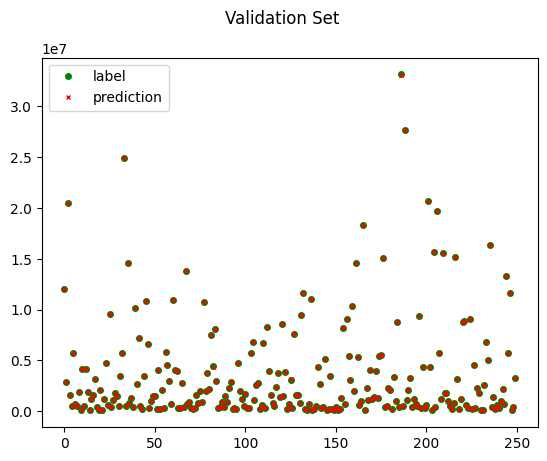

In [9]:
y_valid_pred = poisson.predict(x_valid)
plot(y_valid, y_valid_pred, 'Validation Set')

Text(0, 0.5, 'predict count')

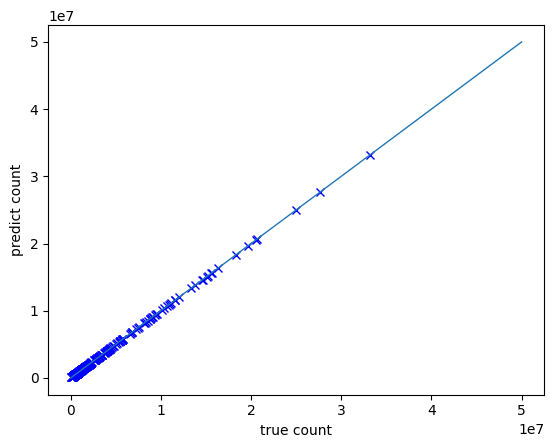

In [16]:
plt.plot(y_valid, y_valid_pred, 'bx', linewidth=2)
plt.plot([0,5e7],[0,5e7], linewidth=1)
plt.xlabel("true count")
plt.ylabel("predict count")